# Improved Pants Classifier CNN

**Changes from the original prototype:**
1. **Transfer Learning** — Uses MobileNetV2 pretrained on ImageNet instead of training from scratch
2. **Data Augmentation** — Random flips, rotation, zoom, contrast to prevent overfitting on ~300 images per class
3. **Better training pipeline** — Learning rate scheduling, early stopping, class weight balancing
4. **Export to TensorFlow.js** — So the model runs directly in the browser for the Drop Your Pants app

### Folder Structure Expected
```
data/
  trendy/       # ~300 images of trendy/cool pants
  not_trendy/   # ~300 images of non-trendy pants
```


In [10]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout,
    GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from tensorflow.keras.callbacks import (
    TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# GPU setup
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(gpus)}")


TensorFlow version: 2.21.0
GPUs available: 0


In [11]:
# ── CONFIG ──
DATA_DIR = os.path.expanduser('~/Desktop/Covid Vaccination Records/data')
IMG_SIZE = 224          # MobileNetV2 expects 224x224
BATCH_SIZE = 16         # Smaller batch for ~600 images
EPOCHS = 30
LEARNING_RATE = 1e-4

# Verify data exists
for cls in os.listdir(DATA_DIR):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if not f.startswith('.')])
        print(f"  {cls}: {count} images")


  not: 307 images
  trendy: 264 images


In [12]:
# ── CLEAN BAD IMAGES ──
import cv2

image_exts = ['jpeg', 'jpg', 'bmp', 'png', 'webp']
removed = 0

for image_class in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, image_class)
    if not os.path.isdir(class_path):
        continue
    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        try:
            img = cv2.imread(image_path)
            if img is None:
                print(f'Cannot read: {image_path}')
                os.remove(image_path)
                removed += 1
                continue
            # Check file extension
            ext = image.rsplit('.', 1)[-1].lower() if '.' in image else ''
            if ext not in image_exts:
                print(f'Bad format ({ext}): {image_path}')
                os.remove(image_path)
                removed += 1
        except Exception as e:
            print(f'Error with {image_path}: {e}')
            os.remove(image_path)
            removed += 1

print(f"\nRemoved {removed} bad images")



Removed 0 bad images


In [13]:
# ── LOAD DATA ──
# Load raw dataset (no augmentation yet — we'll augment in the model)
data = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',        # 0 or 1
    shuffle=True,
    seed=42
)

# Print class names: index 0 = first alphabetical folder, index 1 = second
class_names = data.class_names
print(f"Classes: {class_names}")
print(f"  0 = {class_names[0]}")
print(f"  1 = {class_names[1]}")
print(f"Total batches: {len(data)}")


Found 569 files belonging to 2 classes.
Classes: ['not', 'trendy']
  0 = not
  1 = trendy
Total batches: 36


/var/folders/85/dk9lfxgn0pn97pkglfdgj6vr0000gp/T/ipykernel_68143/986794557.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_idx = int(labels[i].numpy())


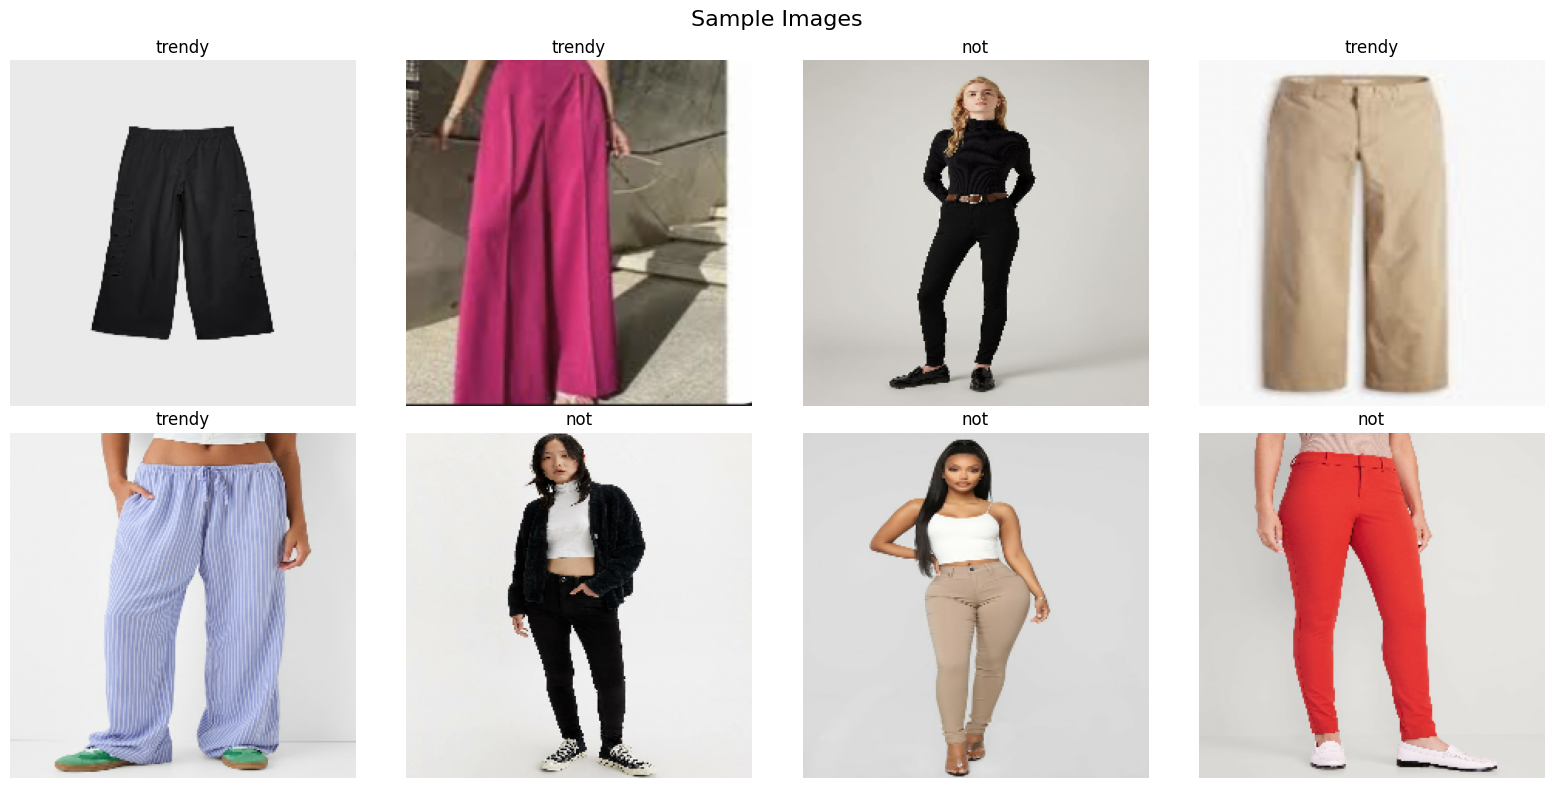

In [14]:
# ── PREVIEW SAMPLES ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
batch = next(iter(data))
images, labels = batch

for i in range(8):
    row, col = i // 4, i % 4
    axes[row][col].imshow(images[i].numpy().astype(int))
    label_idx = int(labels[i].numpy())
    axes[row][col].set_title(class_names[label_idx], fontsize=12)
    axes[row][col].axis('off')

plt.suptitle('Sample Images', fontsize=16)
plt.tight_layout()
plt.show()


In [15]:
# ── SPLIT: 70% train, 15% val, 15% test ──
total = len(data)
train_size = int(total * 0.7)
val_size = int(total * 0.15) + 1
test_size = total - train_size - val_size

# Shuffle before splitting
data = data.shuffle(buffer_size=total, seed=42)

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size)

print(f"Train: {train_size} batches")
print(f"Val:   {val_size} batches")
print(f"Test:  {test_size} batches")

# Scale pixels to [0, 1]
train = train.map(lambda x, y: (x / 255.0, y))
val = val.map(lambda x, y: (x / 255.0, y))
test = test.map(lambda x, y: (x / 255.0, y))

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train = train.prefetch(AUTOTUNE)
val = val.prefetch(AUTOTUNE)
test = test.prefetch(AUTOTUNE)


Train: 25 batches
Val:   6 batches
Test:  5 batches


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.8848095..5.848794].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [22.57816..23.55376].


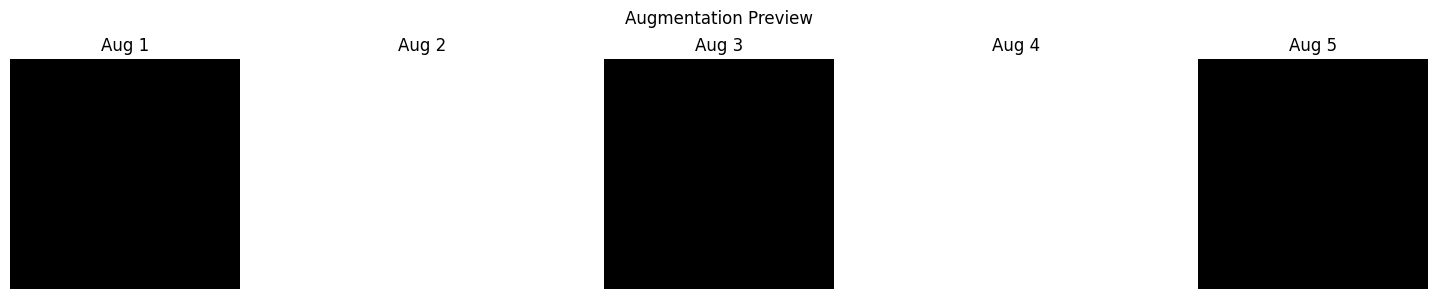

In [16]:
# ── DATA AUGMENTATION (as model layers — runs only during training) ──
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.1),
], name='data_augmentation')

# Preview augmentation on one image
sample_img = next(iter(train))[0][0]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    augmented = data_augmentation(tf.expand_dims(sample_img, 0), training=True)
    axes[i].imshow(augmented[0].numpy())
    axes[i].axis('off')
    axes[i].set_title(f'Aug {i+1}')
plt.suptitle('Augmentation Preview')
plt.tight_layout()
plt.show()


In [17]:
# ── MODEL: MobileNetV2 Transfer Learning ──
# Why MobileNetV2:
#   - Pretrained on ImageNet (1.4M images, 1000 classes) — already knows textures, patterns, shapes
#   - Lightweight enough to convert to TensorFlow.js for browser inference
#   - Much better than training a small CNN from scratch on ~600 images

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,          # Remove ImageNet classification head
    weights='imagenet'
)
base_model.trainable = False    # Freeze pretrained weights initially

# Build full model
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)                   # Augment
x = base_model(x, training=False)               # Feature extraction
x = GlobalAveragePooling2D()(x)                 # Pool features
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)                             # Regularization
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)      # Binary: trendy vs not

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTrainable params: {sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")
print(f"Non-trainable params: {sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights):,}")


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)


Trainable params: 174,849
Non-trainable params: 2,260,544


In [18]:
# ── PHASE 1: Train only the new top layers (base frozen) ──
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    TensorBoard(log_dir='logs/phase1')
]

print("Phase 1: Training top layers (base frozen)...")
hist1 = model.fit(
    train,
    epochs=15,
    validation_data=val,
    callbacks=callbacks
)


Phase 1: Training top layers (base frozen)...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.5220 - loss: 0.8775
Epoch 1: val_accuracy improved from None to 0.60417, saving model to best_model_phase1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 804ms/step - accuracy: 0.5165 - loss: 0.8424 - val_accuracy: 0.6042 - val_loss: 0.6705 - learning_rate: 1.0000e-04
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.5239 - loss: 0.7895
Epoch 2: val_accuracy did not improve from 0.60417
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5400 - loss: 0.7757 - val_accuracy: 0.5312 - val_loss: 0.6849 - learning_rate: 1.0000e-04
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.5626 - loss: 0.7481
Epoch 3: val_accuracy did not improve from 0.60417
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 862ms/step - accuracy: 0.5802 - loss: 0.7475 - val_accuracy: 0.6042 - val_loss: 0.6842 - learning_rate: 1.0000e-04
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.

I0000 00:00:1773378329.661351  729814 shuffle_dataset_op.cc:453] ShuffleDatasetV3:27: Filling up shuffle buffer (this may take a while): 30 of 36
I0000 00:00:1773378329.666151  729814 shuffle_dataset_op.cc:483] Shuffle buffer filled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.5583 - loss: 0.7971
Epoch 8: val_accuracy improved from 0.63542 to 0.68750, saving model to best_model_phase1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 927ms/step - accuracy: 0.5550 - loss: 0.7868 - val_accuracy: 0.6875 - val_loss: 0.6136 - learning_rate: 5.0000e-05
Epoch 9/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.5230 - loss: 0.7863
Epoch 9: val_accuracy did not improve from 0.68750
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 617ms/step - accuracy: 0.5000 - loss: 0.7872 - val_accuracy: 0.6771 - val_loss: 0.6158 - learning_rate: 5.0000e-05
Epoch 10/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.5880 - loss: 0.7722
Epoch 10: val_accuracy did not improve from 0.68750
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 788ms/step - accuracy: 0.5547 - loss: 0.7862 - val_accuracy: 0.6875 - val_loss: 0.6304 - learning_rate: 5.0000e-05
Epoch 11/15


I0000 00:00:1773378407.206282  730700 shuffle_dataset_op.cc:453] ShuffleDatasetV3:27: Filling up shuffle buffer (this may take a while): 31 of 36
I0000 00:00:1773378407.210008  730700 shuffle_dataset_op.cc:483] Shuffle buffer filled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5340 - loss: 0.7246
Epoch 11: val_accuracy improved from 0.68750 to 0.71875, saving model to best_model_phase1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 946ms/step - accuracy: 0.5375 - loss: 0.7353 - val_accuracy: 0.7188 - val_loss: 0.5896 - learning_rate: 5.0000e-05
Epoch 12/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.5682 - loss: 0.7426
Epoch 12: val_accuracy did not improve from 0.71875
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 517ms/step - accuracy: 0.5598 - loss: 0.7111 - val_accuracy: 0.6146 - val_loss: 0.6562 - learning_rate: 5.0000e-05
Epoch 13/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.5519 - loss: 0.7489
Epoch 13: val_accuracy did not improve from 0.71875
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 714ms/step - accuracy: 0.5575 - loss: 0.7301 - val_accuracy: 0.6875 - val_loss: 0.6646 - learning_rate: 5.0000e-05
Epoch 14/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.5389 - loss: 0.7309
Epoch 14: ReduceLROnPlate

In [19]:
# ── PHASE 2: Fine-tune top layers of MobileNetV2 ──
# Unfreeze the last 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile with a much lower learning rate (critical for fine-tuning!)
model.compile(
    optimizer=Adam(learning_rate=1e-5),     # 10x lower
    loss='binary_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable params after unfreezing: {trainable_count:,}")

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_phase2.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    TensorBoard(log_dir='logs/phase2')
]

print("Phase 2: Fine-tuning top base layers...")
hist2 = model.fit(
    train,
    epochs=15,
    validation_data=val,
    callbacks=callbacks_ft
)


Trainable params after unfreezing: 1,701,249
Phase 2: Fine-tuning top base layers...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.5758 - loss: 0.7545
Epoch 1: val_accuracy improved from None to 0.69792, saving model to best_model_phase2.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5394 - loss: 0.8039 - val_accuracy: 0.6979 - val_loss: 0.5982 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.4793 - loss: 0.8957
Epoch 2: val_accuracy did not improve from 0.69792
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5242 - loss: 0.8289 - val_accuracy: 0.6042 - val_loss: 0.6851 - learning_rate: 1.0000e-05
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.4704 - loss: 0.8973
Epoch 3: val_accuracy did not improve from 0.69792
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.4850 - loss: 0.9065 - val_accuracy: 0.6146 - val_loss: 0.5973 - learning_rate: 1.0000e-05
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━

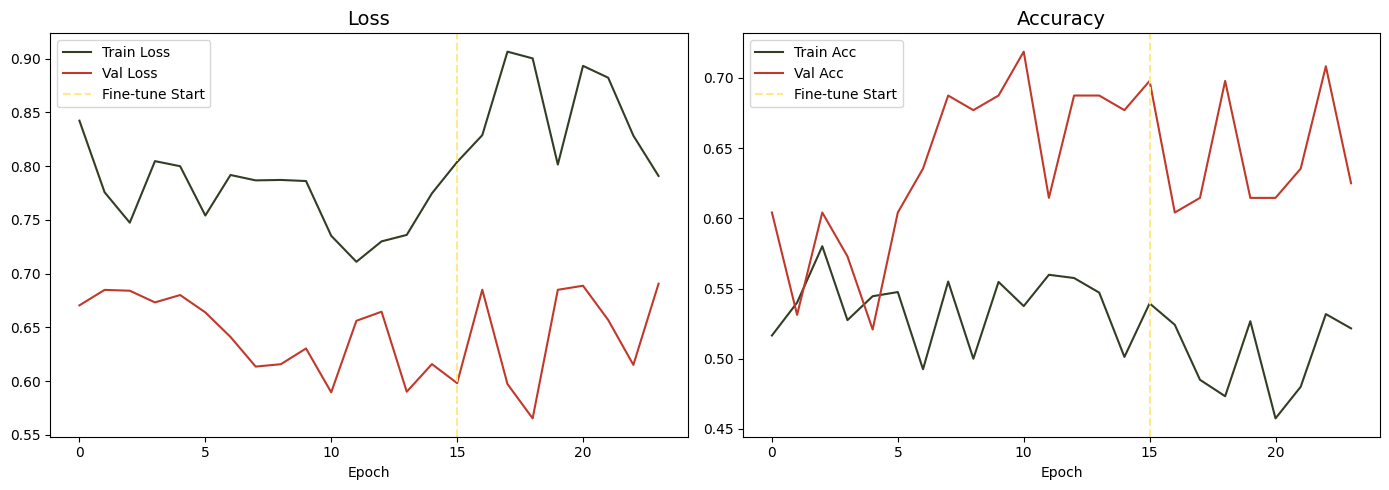

In [20]:
# ── PLOT TRAINING HISTORY ──
def plot_history(hist1, hist2):
    # Combine histories
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    phase1_epochs = len(hist1.history['loss'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(loss, color='#313E24', label='Train Loss')
    ax1.plot(val_loss, color='#c0392b', label='Val Loss')
    ax1.axvline(x=phase1_epochs, color='#FFE988', linestyle='--', label='Fine-tune Start')
    ax1.set_title('Loss', fontsize=14)
    ax1.legend()
    ax1.set_xlabel('Epoch')

    # Accuracy
    ax2.plot(acc, color='#313E24', label='Train Acc')
    ax2.plot(val_acc, color='#c0392b', label='Val Acc')
    ax2.axvline(x=phase1_epochs, color='#FFE988', linestyle='--', label='Fine-tune Start')
    ax2.set_title('Accuracy', fontsize=14)
    ax2.legend()
    ax2.set_xlabel('Epoch')

    plt.tight_layout()
    plt.show()

plot_history(hist1, hist2)


In [21]:
# ── EVALUATE ON TEST SET ──
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

for batch in test.as_numpy_iterator():
    x, y = batch
    yhat = model.predict(x, verbose=0)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

precision_val = pre.result().numpy()
recall_val = re.result().numpy()
accuracy_val = acc.result().numpy()
f1 = 2 * (precision_val * recall_val) / (precision_val + recall_val + 1e-7)

print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy_val:.4f}")


Precision: 0.7500
Recall:    0.3488
F1 Score:  0.4762
Accuracy:  0.5875


In [22]:
# ── TEST ON A SINGLE IMAGE ──
import cv2

test_image_path = 'test_pants.png'  # <-- Change this to your test image

if os.path.exists(test_image_path):
    img = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess
    resized = tf.image.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    scaled = resized / 255.0
    prediction = model.predict(np.expand_dims(scaled, 0))[0][0]

    # class_names[0] is alphabetically first folder
    # sigmoid output: closer to 0 = class 0, closer to 1 = class 1
    label = class_names[1] if prediction > 0.5 else class_names[0]
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"Prediction: {label} ({confidence:.1%} confident)")
else:
    print(f"No test image found at '{test_image_path}' — skipping")


No test image found at 'test_pants.png' — skipping


In [23]:
# ── SAVE KERAS MODEL ──
os.makedirs('models', exist_ok=True)
model.save('models/pants_classifier.keras')
print("Saved: models/pants_classifier.keras")

# Also save as SavedModel format (needed for TF.js conversion)
model.export('models/pants_savedmodel')
print("Saved: models/pants_savedmodel/")


Saved: models/pants_classifier.keras
INFO:tensorflow:Assets written to: models/pants_savedmodel/assets


INFO:tensorflow:Assets written to: models/pants_savedmodel/assets


Saved artifact at 'models/pants_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_334')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  6350549264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6350549088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6350734784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6350736544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6350738480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6041318880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6041569232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6041574512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6041573632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6041573984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6041581200: TensorSpec(shape=(), dtype=tf.resource, n

In [25]:
# ── CONVERT TO TENSORFLOW.JS ──
# Install the converter
!pip install tensorflowjs

import tensorflowjs as tfjs

# Convert the SavedModel to TF.js format
tfjs.converters.convert_tf_saved_model(
    'models/pants_savedmodel',
    'models/tfjs_model'
)

print("\nTensorFlow.js model saved to: models/tfjs_model/")
print("Files created:")
for f in sorted(os.listdir('models/tfjs_model')):
    size = os.path.getsize(os.path.join('models/tfjs_model', f))
    print(f"  {f} ({size / 1024:.0f} KB)")
print("\nCopy the tfjs_model/ folder next to your index.html to use in the browser!")


python(69274) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached tensorflowjs-4.22.0-py3-none-any.whl (89 kB)
  Using cached packaging-23.2-py3-none-any.whl (53 kB)
  Using cached flax-0.10.7-py3-none-any.whl (456 kB)
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)
  Using cached jax-0.6.2-py3-none-any.whl (2.7 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 MB 13.0 MB/s eta 0:00:0000:0100:01
  Using cached tensorflow_decision_forests-1.12.0-cp310-cp310-macosx_12_0_arm64.whl (12.2 MB)
  Using cached tf_keras-2.20.1-py3-none-any.whl (1.7 MB)
  Using cached tensorstore-0.1.78-cp310-cp310-macosx_11_0_arm64.whl (13.8 MB)
  Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl (174 kB)
  Using cached msgpack-1.1.2-cp310-cp310-macosx_11_0_arm64.whl (83 kB)
  Using cached orbax_checkpoint-0.11.33-py3-none-any.whl (696 kB)
  Using cached optax-0.2.7-py3-none-any.whl (399 kB)
  Using cached treescope-0.1.10-py3-none-any.whl (182 kB)
  Using ca

ModuleNotFoundError: No module named 'tensorflowjs'

## Using in the Browser

After conversion, copy the `models/tfjs_model/` folder to sit alongside your `index.html`. The HTML app loads this model and runs inference directly in the browser.

**Important — Class Mapping:**
- `tf.keras.utils.image_dataset_from_directory` assigns labels alphabetically
- So if your folders are `not_trendy/` and `trendy/`: **0 = not_trendy, 1 = trendy**
- The sigmoid output: **> 0.5 = trendy (cool), < 0.5 = not trendy (not cool)**
- The updated HTML handles this automatically

**Folder naming matters!** If your folders are named differently, check `class_names` output above and update the HTML accordingly.
